In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import silhouette_score, pairwise_distances
from sklearn.decomposition import PCA

# Load data
df_selected = pd.read_csv('ga_selected_features2.csv')
df_original = pd.read_csv('cleaned_data (1).csv')

# Features for clustering
X = df_selected.astype(float).values

print("Shape:", X.shape)
df_selected.head()

Shape: (31671, 6)


,loan_percent_income,loan_intent_HOMEIMPROVEMENT,loan_grade_B,loan_grade_C,loan_grade_E,cb_person_default_on_file_Y
0,-0.656393,False,True,False,False,False
1,3.744111,False,False,True,False,False
2,3.369600,False,False,True,False,False
3,3.556855,False,False,True,False,True
4,0.748023,False,False,False,False,False


In [16]:
def run_kmedoids(X, k, max_iter=50):
    np.random.seed(42)
    n_samples = X.shape[0]

    # Initialize medoids randomly
    medoids_indices = np.random.choice(n_samples, k, replace=False)
    medoids = X[medoids_indices]

    for _ in range(max_iter):
        # Assign clusters
        distances = pairwise_distances(X, medoids, metric='manhattan')
        labels = np.argmin(distances, axis=1)

        new_medoids_indices = np.copy(medoids_indices)

        # Update medoids
        for cluster_id in range(k):
            cluster_indices = np.where(labels == cluster_id)[0]

            if len(cluster_indices) == 0:
                continue

            dist_matrix = pairwise_distances(
                X[cluster_indices], X[cluster_indices], metric='manhattan'
            )

            new_medoids_indices[cluster_id] = cluster_indices[
                np.argmin(dist_matrix.sum(axis=1))
            ]

        # Stop if no change
        if np.array_equal(new_medoids_indices, medoids_indices):
            break

        medoids_indices = new_medoids_indices
        medoids = X[medoids_indices]

    return medoids_indices, labels

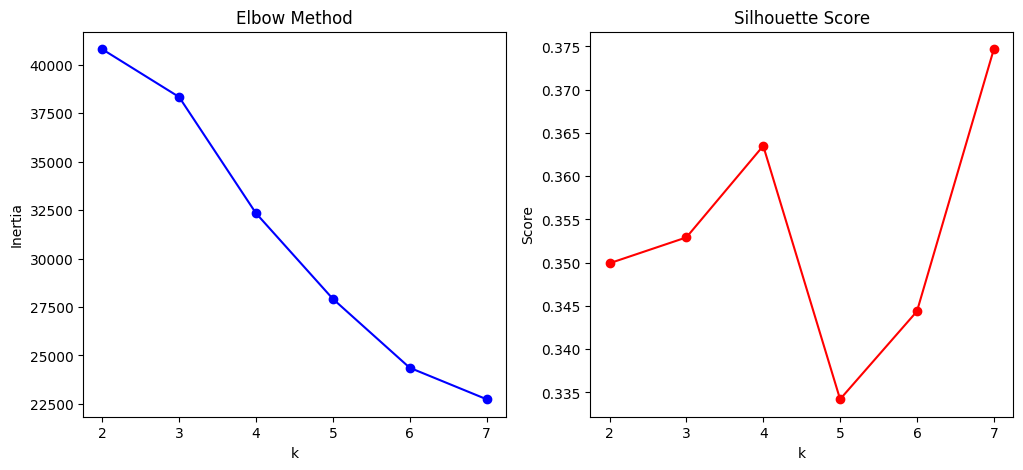

In [17]:
range_n_clusters = range(2, 8)
inertia_scores = []
silhouette_avg = []

np.random.seed(42)

for k in range_n_clusters:
    idx, labels = run_kmedoids(X, k)
    medoids = X[idx]

    # Elbow (Inertia)
    dist = pairwise_distances(X, medoids, metric='manhattan')
    inertia_scores.append(np.sum(np.min(dist, axis=1)))

    # Silhouette (sampled for speed)
    sample_idx = np.random.choice(len(X), 5000, replace=False)
    sil = silhouette_score(
        X[sample_idx],
        labels[sample_idx],
        metric='manhattan'
    )
    silhouette_avg.append(sil)

# Plot
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(range_n_clusters, inertia_scores, 'bo-')
plt.title('Elbow Method')
plt.xlabel('k')
plt.ylabel('Inertia')

plt.subplot(1,2,2)
plt.plot(range_n_clusters, silhouette_avg, 'ro-')
plt.title('Silhouette Score')
plt.xlabel('k')
plt.ylabel('Score')

plt.show()

In [35]:
best_k = 4

In [29]:
best_medoids_idx, final_labels = run_kmedoids(X, k=best_k)

df_original['cluster'] = final_labels

df_original.head()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length,person_home_ownership_OTHER,person_home_ownership_OWN,...,loan_intent_PERSONAL,loan_intent_VENTURE,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G,cb_person_default_on_file_Y,cluster
0,21,9600,5.0,1000,0.1114,0,0.10,2,False,True,...,False,False,True,False,False,False,False,False,False,2
1,25,9600,1.0,5500,0.1287,1,0.57,3,False,False,...,False,False,False,True,False,False,False,False,False,1
2,23,65500,4.0,35000,0.1523,1,0.53,2,False,False,...,False,False,False,True,False,False,False,False,False,1
3,24,54400,8.0,35000,0.1427,1,0.55,4,False,False,...,False,False,False,True,False,False,False,False,True,1
4,21,9900,2.0,2500,0.0714,1,0.25,2,False,True,...,False,True,False,False,False,False,False,False,False,1


In [30]:
print("Cluster Sizes:")
print(df_original['cluster'].value_counts())

Cluster Sizes:
cluster
3    10177
2     9643
1     8900
0     2951
Name: count, dtype: int64


In [31]:
representative_customers = df_original.iloc[best_medoids_idx]

print("Medoids (Representative Customers):")
representative_customers[
    ['person_income', 'loan_amnt', 'loan_percent_income', 'loan_status']
]

Medoids (Representative Customers):


,person_income,loan_amnt,loan_percent_income,loan_status
3311,70000,11000,0.16,0
55,128000,30000,0.23,0
237,14400,2100,0.15,0
173,200000,18000,0.09,0


In [32]:
cluster_analysis = df_original.groupby('cluster').agg({
    'loan_status': 'mean',
    'person_income': 'mean',
    'loan_percent_income': 'mean',
    'loan_amnt': 'mean'
}).rename(columns={'loan_status': 'Default_Rate'}).sort_values('Default_Rate', ascending=False)

print(cluster_analysis)

         Default_Rate  person_income  loan_percent_income     loan_amnt
cluster                                                                
1            0.356629   50833.355843             0.256787  12517.907303
0            0.285327   70091.630973             0.180176  10845.035581
2            0.156175   66687.240382             0.170418   9734.543192
3            0.139236   76962.587305             0.091089   6479.814778


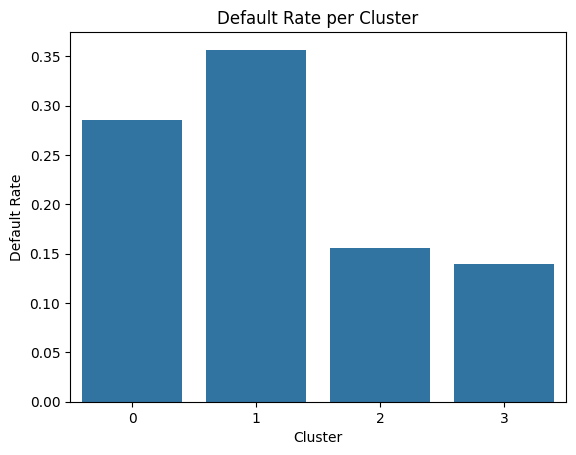

In [33]:
sns.barplot(
    x=cluster_analysis.index,
    y=cluster_analysis['Default_Rate']
)

plt.title('Default Rate per Cluster')
plt.xlabel('Cluster')
plt.ylabel('Default Rate')
plt.show()

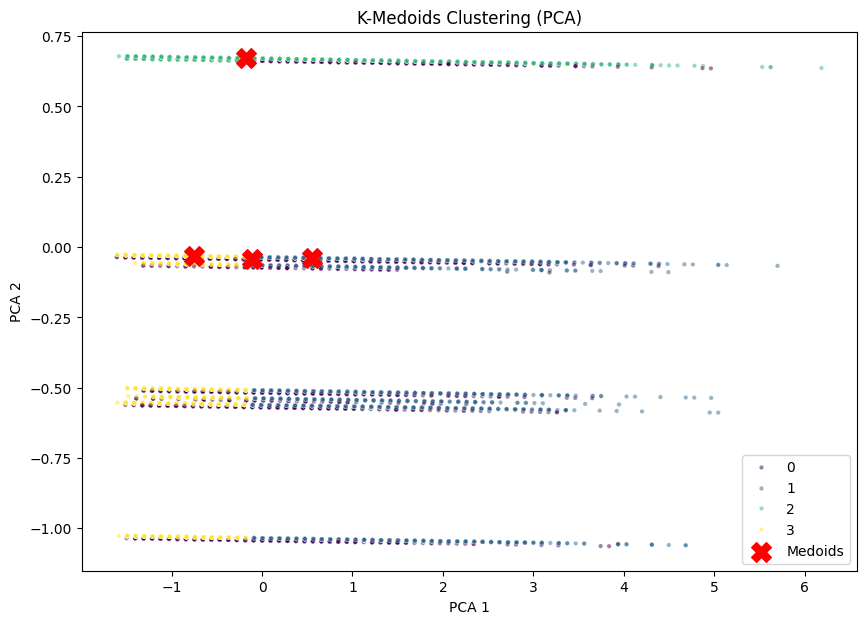

In [34]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

medoids_pca = X_pca[best_medoids_idx]

plt.figure(figsize=(10,7))

sns.scatterplot(
    x=X_pca[:,0],
    y=X_pca[:,1],
    hue=final_labels,
    palette='viridis',
    alpha=0.5,
    s=10
)

plt.scatter(
    medoids_pca[:,0],
    medoids_pca[:,1],
    c='red',
    marker='X',
    s=200,
    label='Medoids'
)

plt.title('K-Medoids Clustering (PCA)')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.legend()
plt.show()

# K-Medoids Clustering Analysis

## Objective
The main goal of this task is to apply **K-Medoids clustering** to the dataset in order to identify natural groups of customers. We aim to determine the optimal number of clusters and analyze the characteristics of each group to understand their financial behavior.

---

## Methodology

### Data Preparation
* We used the dataset after applying feature selection via a **Genetic Algorithm**.
* The features are scaled and standardized, making them ideal for distance-based algorithms like K-Medoids.

### Why K-Medoids?
We chose **K-Medoids** over K-Means because:
1. **Robustness:** It is more resistant to outliers and noise.
2. **Interpretability:** It uses actual data points (medoids) as cluster centers rather than artificial averages.
3. **Manhattan Distance:** It works effectively with the binary and scaled features present in our data.

### Selecting the Number of Clusters
We evaluated values of $k$ from 2 to 7 using:
* **Elbow Method:** To observe the reduction in inertia.
* **Silhouette Score:** To measure cluster separation.

> **Decision:** Although $k=7$ achieved a slightly higher silhouette score, the improvement over $k=4$ was minimal (approx. 0.02). We selected **$k=4$** to maintain a simpler, more actionable, and interpretable structure for business decision-making.

---

## Cluster Results

### Cluster Distribution
| Cluster | Number of Samples | Percentage |
| :--- | :--- | :--- |
| **Cluster 0** | 2,951 | 9.3% |
| **Cluster 1** | 8,900 | 28.1% |
| **Cluster 2** | 9,643 | 30.4% |
| **Cluster 3** | 10,177 | 32.1% |

### Statistical Summary (Averages)
| Cluster | Default Rate | Avg Income | Loan % Income | Loan Amount |
| :--- | :--- | :--- | :--- | :--- |
| **Cluster 1** | **0.357** | 50,833 | **0.257** | 12,517 |
| **Cluster 0** | 0.285 | 70,091 | 0.180 | 10,845 |
| **Cluster 2** | 0.156 | 66,687 | 0.170 | 9,734 |
| **Cluster 3** | **0.139** | **76,962** | **0.091** | 6,479 |

---

## Cluster Interpretation

### **Cluster 1: High Risk**
* **Default Rate:** Highest in the dataset.
* **Characteristics:** Lower income levels combined with the highest loan-to-income ratio.
* **Profile:** These customers represent the most vulnerable group with a high debt burden.

### **Cluster 0: Medium Risk**
* **Default Rate:** Moderate to High.
* **Characteristics:** Good income levels but with a significant loan burden.
* **Profile:** Relatively stable, yet they carry a notable risk factor that requires monitoring.

### **Cluster 2: Low Risk**
* **Default Rate:** Low.
* **Characteristics:** Moderate income and controlled loan usage.
* **Profile:** Significantly safer than the previous groups, representing reliable borrowers.

### **Cluster 3: Lowest Risk (Prime)**
* **Default Rate:** Lowest.
* **Characteristics:** Highest average income and very low loan-to-income percentage.
* **Profile:** The safest and most financially stable customers in the portfolio.

---

## Key Observations
* **Risk Correlation:** A higher `loan_percent_income` is the strongest indicator of an increased default rate.
* **Income Stability:** Customers with higher income and lower loan burdens consistently fall into the low-risk categories.
* **Segmentation Utility:** The clusters clearly distinguish between "Prime" borrowers and "High-Risk" individuals.

---

## Conclusion
K-Medoids clustering successfully segmented the customers into **4 distinct risk profiles**. This simplification allows the business to:
1. Automate risk evaluation for new loan applications.
2. Customize interest rates based on the cluster's risk level.
3. Improve overall portfolio stability by identifying high-risk segments early.